# Final ResNet18 Pipeline

In [1]:
# import needed libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import json
from collections import defaultdict
import shutil
import cv2
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from pycocotools.coco import COCO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Data Loadiing

Loading and inspecting the data

In [2]:
# load the metadata from dataset.csv

metadata = pd.read_csv('FracAtlas/dataset.csv')
print("Shape of the dataset", metadata.shape)
# prints in a table format the first 10 entries of the dataset.csv dataset
metadata.head(10)

Shape of the dataset (4083, 13)


,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1
5,IMG0000005.jpg,0,1,0,0,0,0,1,0,0,0,1,1
6,IMG0000006.jpg,1,0,0,0,0,0,1,0,0,0,1,1
7,IMG0000007.jpg,1,0,0,0,0,0,0,0,0,0,0,1
8,IMG0000008.jpg,0,1,0,0,0,0,1,0,0,0,1,1
9,IMG0000009.jpg,0,1,0,0,0,0,0,0,0,0,0,1


In [3]:
# check image type
img = cv2.imread("FracAtlas/images/Fractured/IMG0000019.jpg")
print(img.shape)

(2880, 2304, 3)


## Median Frequency Balancing

Originally we thought to divide the data into image location folders (hand, leg, shoulder, mixed) and to apply MFB to these labels to assist with class imbalance. However, this was proving to be an ineffective approach, and was unused in our final model versions.

In our final model versions, we ended up using the "FracAtlas/images/sorted_images/Combined/all" folder, which is justa  folder that contains all the images (fractured and non-fractured) in the dataset after pre-processing has been applied.

In [4]:
# median frequency balancing between all images (fractured and non-fractured)

label = [ 'hand', 'leg','hip','shoulder','mixed']

def estimate_weights_mfb(label):
    class_weights = np.zeros_like(label, dtype=float)
    counts = np.zeros_like(label)
    for i,l in enumerate(label):
        counts[i] = metadata[metadata[l] == 1].shape[0]
    counts = counts.astype(float)
    median_freq = np.median(counts)
    for i, label in enumerate(label):
        class_weights[i] = median_freq / counts[i]
    return class_weights

classweight= estimate_weights_mfb(label)

for i in range(len(label)):
    print(label[i],":", classweight[i])

hand : 0.258777633289987
leg : 0.17509898812142544
hip : 1.1775147928994083
shoulder : 1.140401146131805
mixed : 1.0


## Data Augmentation

- Normalized images to ensure that each input parameter has a similar data distribution
- Flipping the image horizontally: *RandomHorizontalFlip()*
- Rotating image 60 degrees: *RandomRotation()* . 60 degrees is chosen as best practice. You can experiment with other angles.

The augmentation is applied using the *transform.Compose()* function of Pytorch.

In [5]:
# data augmentation

# normalization values for pretrained resnet on Imagenet
norm_mean = (0.485, 0.456, 0.406)
norm_std = (0.229, 0.224, 0.225)

batch_size = 128
validation_batch_size = 10
test_batch_size = 10

# We compute the weights of individual classes and convert them to tensors
class_weights = estimate_weights_mfb(label)
class_weights = torch.FloatTensor(class_weights)

transform_train = transforms.Compose([
                    transforms.Resize((224,224)),
                    transforms.RandomHorizontalFlip(),
                    transforms.RandomRotation(degrees=60),
                    transforms.ToTensor(),
                    transforms.Normalize(norm_mean, norm_std),
                    ])

transform_test = transforms.Compose([
                    transforms.Resize((224,224)),
                    transforms.ToTensor(),
                    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
                    ])


## Model Architecture

The ResNet18UNet model is a U-Net-style neural network designed for binary image segmentation (such as detecting fractures in medical images like our project). It uses a pretrained ResNet-18 as the encoder to extract hierarchical features from the input image at multiple spatial resolutions. These features are progressively downsampled through layers enc1 to enc5. The decoder then upsamples the features using transposed convolutions in up_block layers, and combines them with corresponding encoder outputs via skip connections to preserve spatial detail. 
Finally, a 1x1 convolution layer generates a single-channel output map representing raw segmentation logits, which can be converted to probabilities using a sigmoid function during evaluation.

In [6]:
class ResNet18UNet(nn.Module):
    def __init__(self, n_classes=1):  # binary segmentation (fracture or not)
        super(ResNet18UNet, self).__init__()
        
        # Load pretrained ResNet-18
        resnet = torchvision.models.resnet18(pretrained=True)

        # Encoder from ResNet-18
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 64, /2
        self.enc2 = nn.Sequential(resnet.maxpool, resnet.layer1)          # 64, /4
        self.enc3 = resnet.layer2  # 128, /8
        self.enc4 = resnet.layer3  # 256, /16
        self.enc5 = resnet.layer4  # 512, /32

        # Decoder
        self.up4 = self.up_block(512, 256)
        self.up3 = self.up_block(256, 128)
        self.up2 = self.up_block(128, 64)
        self.up1 = self.up_block(64, 64)

        # Final 1x1 conv for binary mask output
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def up_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        # Decoder with skip connections
        d4 = self.up4(e5) + e4
        d3 = self.up3(d4) + e3
        d2 = self.up2(d3) + e2
        d1 = self.up1(d2) + e1

        out = self.final_conv(d1)
        return out  # raw logits, apply sigmoid during loss or evaluation

## Model 1

Below is the implementation for the first model, which is the model without oversampling applied to the data

In [7]:
model = ResNet18UNet(n_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss()  # binary mask loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/Users/ariakieras/opt/anaconda3/envs/Deep_Learning/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ariakieras/opt/anaconda3/envs/Deep_Learning/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Applying Labels and Creating Masks

This custom dataset loads X-ray images and their corresponding binary fracture masks from COCO-style annotations, applies consistent transformations to both, and returns them for use in a segmentation model.

In [8]:
class FracAtlasCocoDataset(Dataset):
    def __init__(self, images_dir, ann_path, image_ids, transform=None):
        """
        images_dir: path to folder with X-ray images
        ann_path: path to COCO annotation JSON file
        image_ids: list of image file names to include (train/val split)
        transform: torchvision transforms to apply
        """
        self.images_dir = images_dir
        self.coco = COCO(ann_path)
        self.image_ids = [
            img['id'] for img in self.coco.dataset['images']
            if img['file_name'] in image_ids
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_dir, img_info['file_name'])

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Create empty mask
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

        # Get annotations for the image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        for ann in anns:
            m = self.coco.annToMask(ann)
            mask = np.maximum(mask, m)

        # Convert to PIL Image for transforms
        mask = Image.fromarray(mask)

        if self.transform:
            # Apply the same transform to both image and mask
            image = self.transform(image)
            mask = TF.resize(mask, image.shape[1:])  # resize mask to match image (if needed)
            mask = TF.to_tensor(mask)
            mask = (mask > 0).float()  # ensures binary (0 or 1)

        return image, mask

## Load data for Model 1

Below is loading the pre-processed data to train, validate, and test Model 1

In [9]:
train_csv = 'FracAtlas/Utilities/Fracture Split/train_combined.csv'
val_csv = 'FracAtlas/Utilities/Fracture Split/valid_combined.csv'
test_csv = 'FracAtlas/Utilities/Fracture Split/test_combined.csv'
ann_path = "FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json"
images_dir = "FracAtlas/images/sorted_images/Combined/all"

# Load train/val splits
train_ids = pd.read_csv(train_csv)['image_id'].tolist()
val_ids = pd.read_csv(val_csv)['image_id'].tolist()

# Datasets
train_dataset = FracAtlasCocoDataset(images_dir, ann_path, train_ids, transform=transform_train)
val_dataset = FracAtlasCocoDataset(images_dir, ann_path, val_ids, transform=transform_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


## How Imbalanced is the Data?

The code cell below estimates the degree of class imbalance by calculating the ratio of fracture pixels (foreground) to the total number of pixels (foreground + background) in a batch of training masks. Iterating through one batch from the train_loader, sums all pixel values in the mask (which are 1 for fractures and 0 for background), and divides by the total number of pixels to compute the fracture pixel ratio. 
This ratio indicates how sparse the fracture regions are in the dataset, which is often crucial in medical imaging where fractures may occupy only a small portion of the image. The result helps determine whether techniques like class weighting or oversampling are needed to address imbalance and improve model performance.

With a Fracture pixel ratio of 0.005752, this means that only 0.5752% of the pixels in the sampled training batch are labeled as fractures, while the remaining 99.4248% are background, indicating a heavily imbalanced dataset.

In [10]:
total_pixels = 0
fracture_pixels = 0

for _, mask in train_loader:
    fracture_pixels += mask.sum().item()
    total_pixels += mask.numel()
    break  

fracture_ratio = fracture_pixels / total_pixels
print(f"Fracture pixel ratio: {fracture_ratio:.6f}")

Fracture pixel ratio: 0.005752


In [11]:
# Compute pos_weight dynamically
pos_weight_value = 1.0 / (fracture_ratio + 1e-8)
print(f"Using pos_weight={pos_weight_value:.2f}")

# Set loss with pos_weight
pos_weight = torch.tensor([pos_weight_value]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Using pos_weight=173.84


## Evaluation Metrics

The below code cell contains multiple functions that will provide different metric scores. These functions are called in both training loops (before oversampling and after oversampling) to ensure that metrics between these traiing loops are consistent.

In [12]:
def dice_score(pred, target, smooth=1.):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1.):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def precision_score(pred, target, eps=1e-8):
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    return (tp + eps) / (tp + fp + eps)

def recall_score(pred, target, eps=1e-8):
    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()
    return (tp + eps) / (tp + fn + eps)

def f1_score(pred, target, eps=1e-8):
    precision = precision_score(pred, target, eps)
    recall = recall_score(pred, target, eps)
    return (2 * precision * recall + eps) / (precision + recall + eps)

def accuracy_score(pred, target, eps=1e-8):
    correct = (pred == target).float().sum()
    total = target.numel()
    return correct / (total + eps)

def save_checkpoint(model, optimizer, epoch, path="checkpoint.pth"):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)

def compute_confusion_matrix(preds, targets):
    """
    Computes TP, TN, FP, FN for binary segmentation.
    Args:
        preds (Tensor): shape (B, 1, H, W)
        targets (Tensor): shape (B, 1, H, W)
    Returns:
        Dictionary with TP, TN, FP, FN
    """
    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = ((preds == 1) & (targets == 1)).sum().item()
    TN = ((preds == 0) & (targets == 0)).sum().item()
    FP = ((preds == 1) & (targets == 0)).sum().item()
    FN = ((preds == 0) & (targets == 1)).sum().item()

    return {"TP": TP, "TN": TN, "FP": FP, "FN": FN}

def compute_mAP(preds, targets, thresholds=np.arange(0.5, 1.0, 0.05), eps=1e-8):
    """
    Computes mean Average Precision (mAP) across thresholds for binary segmentation.
    preds and targets should be torch tensors of shape (B, 1, H, W)
    """
    preds = preds.view(-1).cpu().numpy()
    targets = targets.view(-1).cpu().numpy()

    APs = []

    for thresh in thresholds:
        binarized = (preds >= thresh).astype(np.uint8)

        TP = np.logical_and(binarized == 1, targets == 1).sum()
        FP = np.logical_and(binarized == 1, targets == 0).sum()
        FN = np.logical_and(binarized == 0, targets == 1).sum()

        precision = TP / (TP + FP + eps)
        recall = TP / (TP + FN + eps)

        AP = precision * recall  # proxy for real AP (simplified)
        APs.append(AP)

    mAP = np.mean(APs)
    return mAP

## Training Model 1

Below is the training loop for our first model, which will run for 50 epochs

In [13]:
train_losses = []
train_dices = []
train_ious = []
train_f1s = []
train_precisions = []
train_recalls = []
train_accuracies = []

val_losses = []
val_dices = []
val_ious = []
val_f1s = []
val_precisions = []
val_recalls = []
val_accuracies = []
val_maps = []

num_epochs = 50
best_val_dice = 0.0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_f1 = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_acc = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        outputs = F.interpolate(outputs, size=masks.shape[2:], mode='bilinear', align_corners=False)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        with torch.no_grad():
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            total_dice += dice_score(preds, masks).item()
            total_iou += iou_score(preds, masks).item()
            total_f1 += f1_score(preds, masks).item()
            total_precision += precision_score(preds, masks).item()
            total_recall += recall_score(preds, masks).item()
            total_acc += accuracy_score(preds, masks).item()

    conf_matrix = {"TP": 0, "TN": 0, "FP": 0, "FN": 0}

    # Average training metrics for this epoch
    avg_train_loss = total_loss / len(train_loader)
    avg_train_dice = total_dice / len(train_loader)
    avg_train_iou = total_iou / len(train_loader)
    avg_train_f1 = total_f1 / len(train_loader)
    avg_train_precision = total_precision / len(train_loader)
    avg_train_recall = total_recall / len(train_loader)
    avg_train_acc = total_acc / len(train_loader)

    # Store training metrics
    train_losses.append(avg_train_loss)
    train_dices.append(avg_train_dice)
    train_ious.append(avg_train_iou)
    train_f1s.append(avg_train_f1)
    train_precisions.append(avg_train_precision)
    train_recalls.append(avg_train_recall)
    train_accuracies.append(avg_train_acc)

    # --- VALIDATION ---
    model.eval()
    total_dice = 0.0
    total_iou = 0.0
    total_f1 = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_acc = 0.0
    total_loss_val = 0.0 

    with torch.no_grad():
        all_preds = []
        all_targets = []
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            outputs = F.interpolate(outputs, size=masks.shape[2:], mode='bilinear', align_corners=False)
            loss_val = criterion(outputs, masks)
            total_loss_val += loss_val.item()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            batch_matrix = compute_confusion_matrix(preds, masks)
            for k in conf_matrix:
                conf_matrix[k] += batch_matrix[k]

            total_dice += dice_score(preds, masks).item()
            total_iou += iou_score(preds, masks).item()
            total_f1 += f1_score(preds, masks).item()
            total_precision += precision_score(preds, masks).item()
            total_recall += recall_score(preds, masks).item()
            total_acc += accuracy_score(preds, masks).item()
            all_preds.append(probs.cpu())
            all_targets.append(masks.cpu())

    avg_val_loss = total_loss_val / len(val_loader)
    avg_val_dice = total_dice / len(val_loader)
    avg_val_iou = total_iou / len(val_loader)
    avg_val_f1 = total_f1 / len(val_loader)
    avg_val_precision = total_precision / len(val_loader)
    avg_val_recall = total_recall / len(val_loader)
    avg_val_acc = total_acc / len(val_loader)

    val_losses.append(avg_val_loss)
    val_dices.append(avg_val_dice)
    val_ious.append(avg_val_iou)
    val_f1s.append(avg_val_f1)
    val_precisions.append(avg_val_precision)
    val_recalls.append(avg_val_recall)
    val_accuracies.append(avg_val_acc)

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    val_map = compute_mAP(all_preds, all_targets)
    val_maps.append(val_map)

    print(f"Epoch {epoch+1}/{num_epochs} | "
      f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
      f"Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f} | "
      f"mAP: {val_map:.4f} | "
      f"F1: {avg_val_f1:.4f} | Precision: {avg_val_precision:.4f} | Recall: {avg_val_recall:.4f} | Acc: {avg_val_acc:.4f}")

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        save_checkpoint(model, optimizer, epoch)
        print("Checkpoint saved!")

Epoch 1/50 | Train Loss: 1.1148 | Val Loss: 0.8698 | Dice: 0.0725 | IoU: 0.0386 | mAP: 0.0049 | F1: 0.0725 | Precision: 0.0393 | Recall: 0.6029 | Acc: 0.9127
Checkpoint saved!
Epoch 2/50 | Train Loss: 0.8865 | Val Loss: 0.7061 | Dice: 0.0562 | IoU: 0.0291 | mAP: 0.0206 | F1: 0.0561 | Precision: 0.0292 | Recall: 0.8634 | Acc: 0.8705
Epoch 3/50 | Train Loss: 0.7710 | Val Loss: 0.5837 | Dice: 0.0391 | IoU: 0.0200 | mAP: 0.0233 | F1: 0.0390 | Precision: 0.0200 | Recall: 0.9318 | Acc: 0.8053
Epoch 4/50 | Train Loss: 0.7357 | Val Loss: 0.5829 | Dice: 0.0384 | IoU: 0.0197 | mAP: 0.0253 | F1: 0.0384 | Precision: 0.0197 | Recall: 0.9330 | Acc: 0.8041
Epoch 5/50 | Train Loss: 0.6936 | Val Loss: 0.6280 | Dice: 0.0438 | IoU: 0.0225 | mAP: 0.0239 | F1: 0.0437 | Precision: 0.0225 | Recall: 0.8492 | Acc: 0.8415
Epoch 6/50 | Train Loss: 0.6464 | Val Loss: 0.5536 | Dice: 0.0454 | IoU: 0.0233 | mAP: 0.0296 | F1: 0.0453 | Precision: 0.0233 | Recall: 0.8901 | Acc: 0.8511
Epoch 7/50 | Train Loss: 0.6439 | 

## Plot mAP

Below we plot the mAP metric, showing our resulting 0.06 score.

A mAP score of 0.06 is low and suggests model 1 isn't reliably identifying fracture regions. This is an expected outcome for imbalanced data.

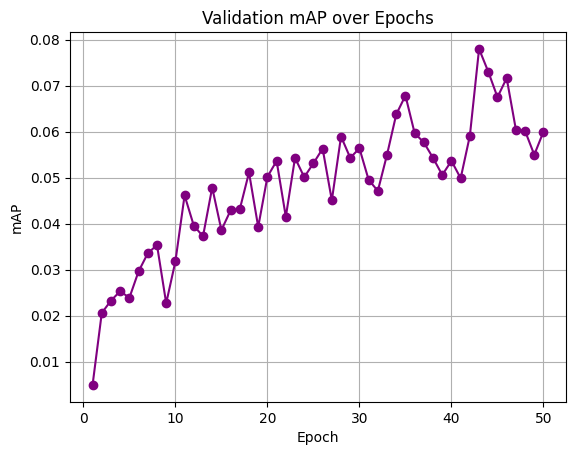

In [14]:
plt.plot(range(1, num_epochs + 1), val_maps, 'o-', color='purple')
plt.title("Validation mAP over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.grid(True)
plt.show()

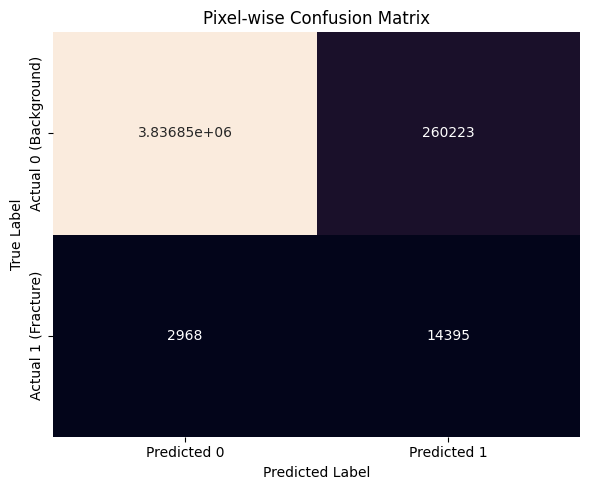

In [15]:
# Build confusion matrix DataFrame
cm_df = pd.DataFrame(
    [[conf_matrix['TN'], conf_matrix['FP']],
     [conf_matrix['FN'], conf_matrix['TP']]],
    index=["Actual 0 (Background)", "Actual 1 (Fracture)"],
    columns=["Predicted 0", "Predicted 1"]
)

# Display heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='g', cbar=False)
plt.title("Pixel-wise Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Other Model 1 Metrics

Below plots our other metrics for model 1.
Based on these metrics, we can see model 1 is showing some signs of early learning, but is still struggling with accurate segmentation. 
The relatively low validation loss compared to training loss suggests some generalization, but the very low Dice (0.10), IoU (0.05), F1 (0.10), and mAP (0.06) indicate poor localization of fracture regions. 
While the recall is high at 0.83 (meaning model 1 is good at identifying most fracture pixels) it comes at the cost of very low precision (0.05), which reflects a high number of false positives. Overall, model 1 is sensitive but not yet precise.

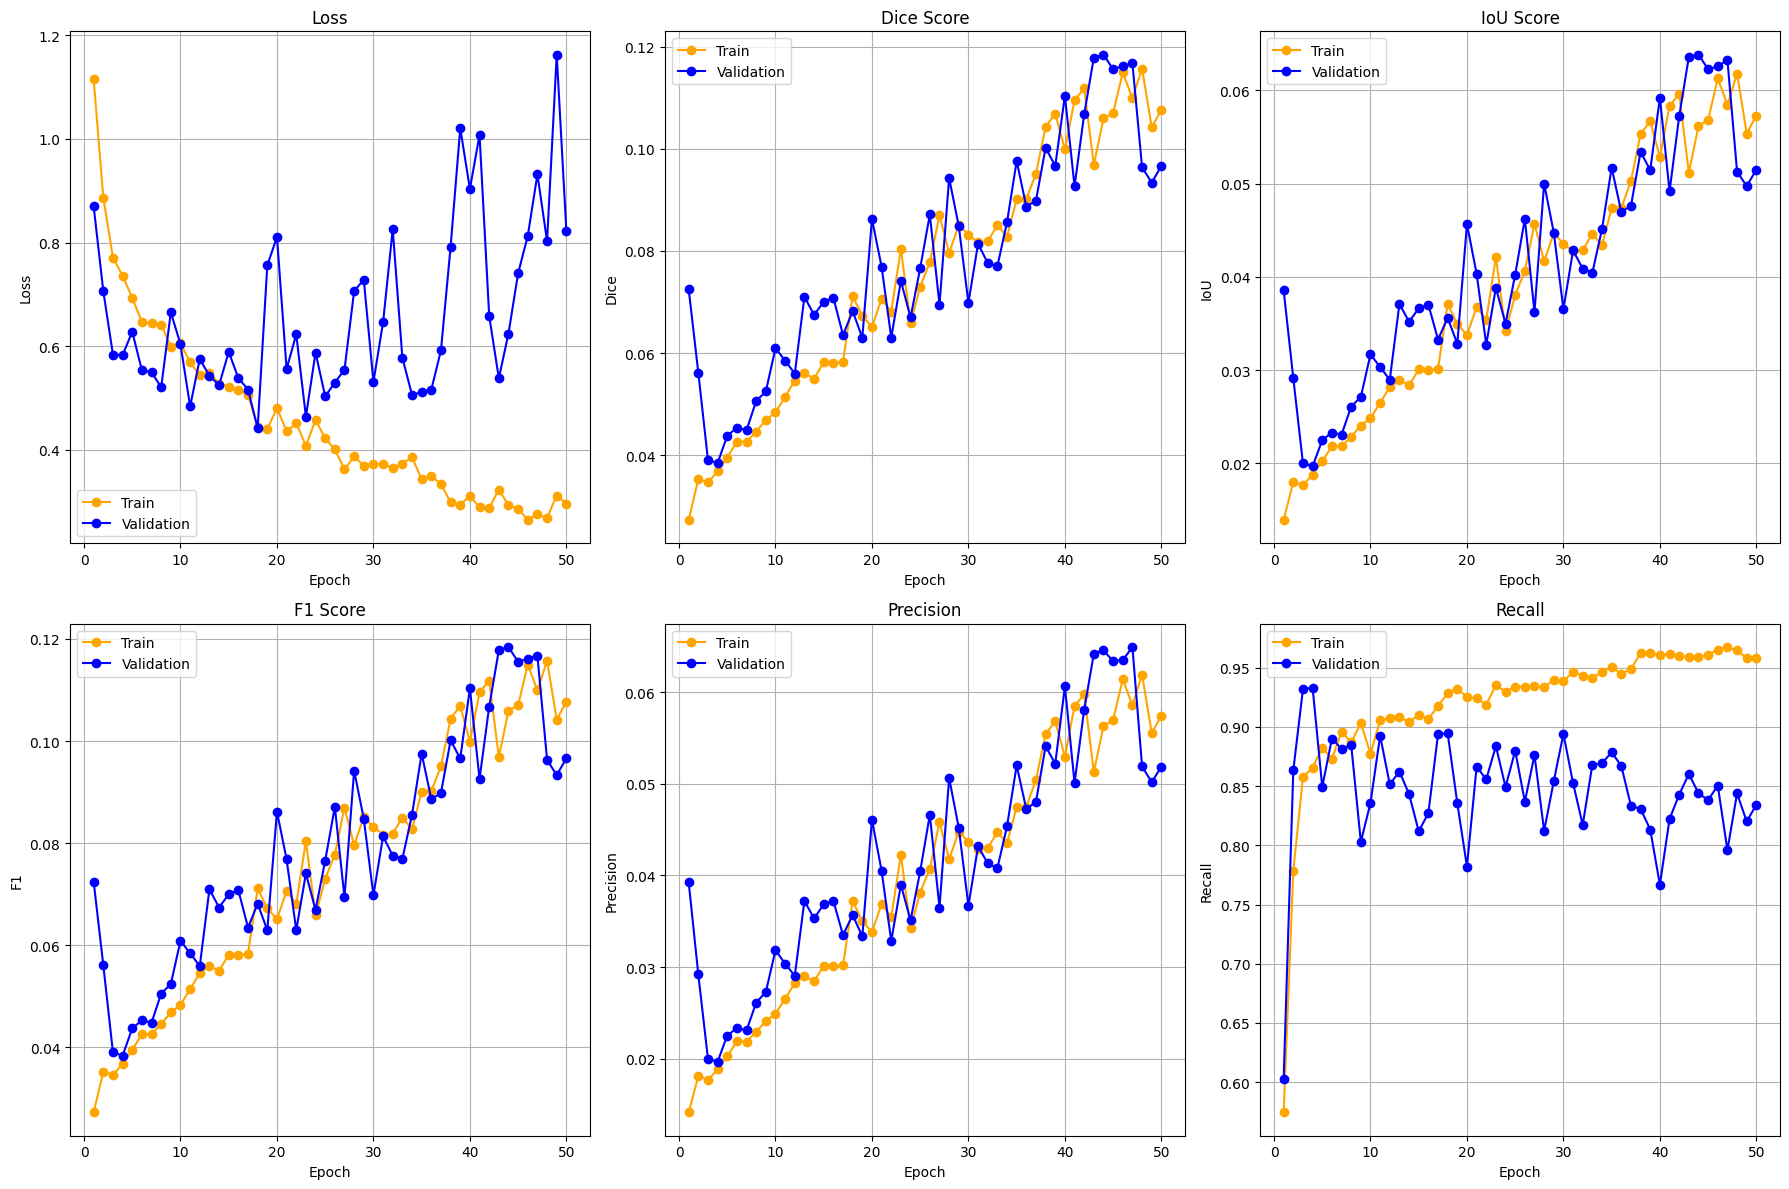

In [16]:
epochs = list(range(1, num_epochs + 1))

def plot_metric(title, train_values, val_values, ylabel):
    plt.plot(epochs, train_values, 'o-', color='orange', label='Train')
    plt.plot(epochs, val_values, 'o-', color='blue', label='Validation')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plot_metric("Loss", train_losses, val_losses, "Loss")

plt.subplot(2, 3, 2)
plot_metric("Dice Score", train_dices, val_dices, "Dice")

plt.subplot(2, 3, 3)
plot_metric("IoU Score", train_ious, val_ious, "IoU")

plt.subplot(2, 3, 4)
plot_metric("F1 Score", train_f1s, val_f1s, "F1")

plt.subplot(2, 3, 5)
plot_metric("Precision", train_precisions, val_precisions, "Precision")

plt.subplot(2, 3, 6)
plot_metric("Recall", train_recalls, val_recalls, "Recall")

plt.tight_layout()
plt.show()

## Predictions

So, lets look at some predictions. Below is a function to imput an image and have our model 1 generate a bounding box around where it thinks a fracture is located.

In [17]:
def show_prediction_with_box(model, dataset, index=0, threshold=0.5):
    model.eval()
    with torch.no_grad():
        # Get image and corresponding image_id
        image, _ = dataset[index]
        image_id = dataset.image_ids[index]
        image_info = dataset.coco.loadImgs(image_id)[0]
        filename = image_info['file_name']

        print(f"Image ID: {filename}")

        input_tensor = image.unsqueeze(0).to(device)

        # Run model
        output = model(input_tensor)
        output = F.interpolate(output, size=image.shape[1:], mode='bilinear', align_corners=False)
        probs = torch.sigmoid(output)
        pred_mask = (probs > threshold).float().cpu().numpy()[0, 0]

        # Convert to bounding boxes using OpenCV
        mask_uint8 = (pred_mask * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Original image as NumPy for plotting
        img_np = image.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())  # Normalize for display
        img_disp = (img_np * 255).astype(np.uint8).copy()

        # Draw bounding boxes
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(img_disp, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Show image and predicted mask
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_disp)
        ax[0].set_title("Predicted Bounding Box")
        ax[0].axis("off")

        ax[1].imshow(pred_mask, cmap='gray')
        ax[1].set_title("Predicted Mask")
        ax[1].axis("off")
        plt.show()

### Prediction 1

Here we see our first image for prediction and the cooresponding mask applied. While the model did okay an getting a bounding box close to the ground truth of the fracture, we see that the model generated a second bounding box when it should not have.

Image ID: IMG0003803.jpg


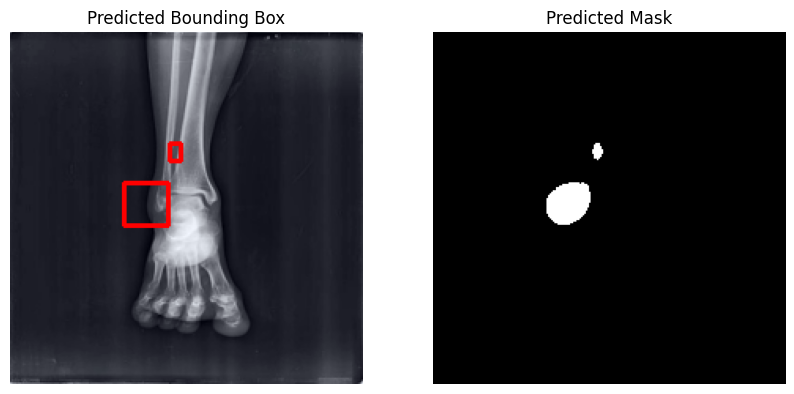

In [42]:
# Show bounding box prediction on test image
show_prediction_with_box(model, val_dataset, index=11)

### Prediction 2

Here we have another prediction, this time with only one bounding box. While the fracture is located in the bounding box, it is not a central location, so model 1 is still poorly predicting where the fractures are.

Image ID: IMG0003798.jpg


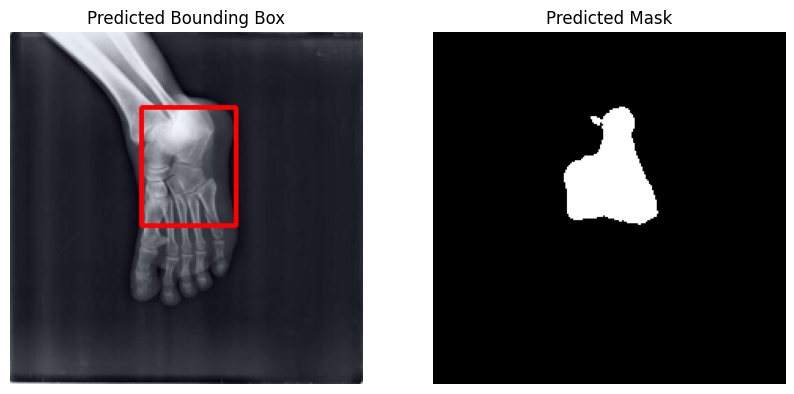

In [33]:
# Show bounding box prediction on test image
show_prediction_with_box(model, val_dataset, index=10)

## Ground truth

Below is a function that will display the original image from the dataset with its provided annotation to show the ground truth of where the fracture is in the image. 
This is helpful to visually compare what the model is predicting to what we should expect.

In [18]:
def show_coco_box_from_original_image(dataset, index=0, image_root="FracAtlas/images/sorted_images/Combined/all"):

    image_id = dataset.image_ids[index]
    image_info = dataset.coco.loadImgs(image_id)[0]
    filename = image_info['file_name']
    filepath = os.path.join(image_root, filename)

    print(f"Raw image with COCO boxes: {filename}")

    # Load original image
    img = cv2.imread(filepath)
    if img is None:
        print("Failed to load image.")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get annotations and draw boxes
    ann_ids = dataset.coco.getAnnIds(imgIds=image_id)
    anns = dataset.coco.loadAnns(ann_ids)

    for i, ann in enumerate(anns):
        x, y, w, h = map(int, ann['bbox'])  # COCO box format
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)  #Green GT box
        print(f"GT Box {i+1}: x={x}, y={y}, w={w}, h={h}")

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title("COCO GT Boxes on Original Image")
    plt.axis("off")
    plt.show()

### Ground Truth 1

As we can see, the fracture was almost located by the model, but not exactly and an extra bounding box was generated.

Raw image with COCO boxes: IMG0003803.jpg
GT Box 1: x=154, y=191, w=16, h=23


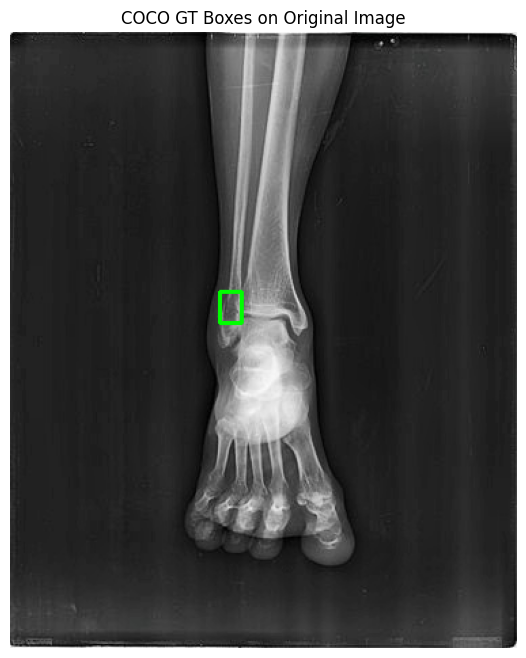

In [20]:
show_coco_box_from_original_image(val_dataset, index=11)

### Ground Truth 2

In this example, the model was farther off from the ground truth, but was able to at least capture the fracture in its generated bounding box.

Raw image with COCO boxes: IMG0003798.jpg
GT Box 1: x=201, y=227, w=27, h=37


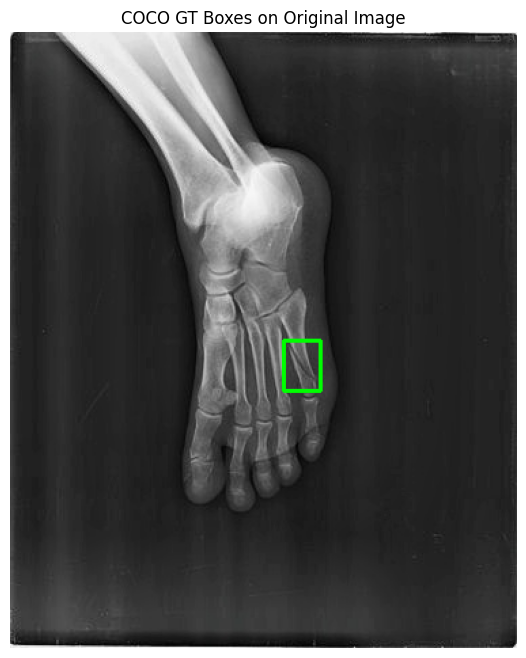

In [34]:
show_coco_box_from_original_image(val_dataset, index=10)

## Apply oversampling

The results from the initial run of the ResNet18 UNet archetecture leave much to be desired, so lets try oversampling. By duplicating the fracture images (from 'FracAtlas/Utilities/Fracture Split/train.csv') and combining them with non-fracture images (from 'FracAtlas/Utilities/Fracture Split/nf_train.csv') such that an instance of fracture image can appear multiple times in the new combined .csv file, we can attampt to balance the dataset in hopes that the model will be able to generalize better.

In [21]:
# oversampling

# Create a new train .csv file and apply oversampling

# Load the CSVs
fracture_df = pd.read_csv('FracAtlas/Utilities/Fracture Split/train.csv')        # fracture images only
nonfracture_df = pd.read_csv('FracAtlas/Utilities/Fracture Split/nf_train.csv')  # non-fracture images only

# Oversample fracture images (4x duplication)
oversampled_fractures = pd.concat([fracture_df] * 4, ignore_index=True)

# Combine and shuffle
combined_df = pd.concat([oversampled_fractures, nonfracture_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42)  # shuffle rows

# Save the result
combined_df[['image_id']].to_csv('FracAtlas/Utilities/Fracture Split/train_combined_balanced.csv', index=False)

print(f"Combined dataset saved with {len(combined_df)} entries.")

Combined dataset saved with 2296 entries.


## Model 2

Below is the definition of the second model for training. Using the same architeture as model 1, this model is used to compare against the first model after oversampling the data in a hope to improve resulting metrics.

In [54]:
model_2 = ResNet18UNet(n_classes=1).to(device)
criterion_2 = nn.BCEWithLogitsLoss()  # binary mask loss
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-4)

/Users/ariakieras/opt/anaconda3/envs/Deep_Learning/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/ariakieras/opt/anaconda3/envs/Deep_Learning/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Load Oversampled data

Mostly the same as before, only loading in the newly oversampled (balanced) training data csv file

In [23]:
train_b_csv = 'FracAtlas/Utilities/Fracture Split/train_combined_balanced.csv'
val_2_csv = 'FracAtlas/Utilities/Fracture Split/valid_combined.csv'
test_2_csv = 'FracAtlas/Utilities/Fracture Split/test_combined.csv'
ann_2_path = "FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json"
images_2_dir = "FracAtlas/images/sorted_images/Combined/all"

# Load train/val splits
train_2_ids = pd.read_csv(train_b_csv)['image_id'].tolist()
val_2_ids = pd.read_csv(val_2_csv)['image_id'].tolist()

# Datasets
train_2_dataset = FracAtlasCocoDataset(images_dir, ann_2_path, train_2_ids, transform=transform_train)
val_2_dataset = FracAtlasCocoDataset(images_dir, ann_2_path, val_2_ids, transform=transform_test)

# DataLoaders
train_2_loader = DataLoader(train_2_dataset, batch_size=8, shuffle=True)
val_2_loader = DataLoader(val_2_dataset, batch_size=4, shuffle=False)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


## How Imbalanced is the Data?

Similar as before, this will help to indicate how imbalanced the data is after oversampling.
Unfortunetly, it is still quite imbalanced even after oversampling, but with some improvement lets see if it will impact our training.

In [92]:
# Estimate how imbalanced your dataset is
total_pixels_2 = 0
fracture_pixels_2 = 0

for _, mask in train_2_loader:
    fracture_pixels_2 += mask.sum().item()
    total_pixels_2 += mask.numel()
    break  

fracture_ratio_2 = fracture_pixels_2 / total_pixels_2
print(f"Fracture pixel ratio: {fracture_ratio_2:.6f}")

Fracture pixel ratio: 0.008420


In [93]:
# Compute pos_weight dynamically
pos_weight_value_2 = 1.0 / (fracture_ratio_2 + 1e-8)
print(f"Using pos_weight={pos_weight_value_2:.2f}")

# Set loss with pos_weight
pos_weight_2 = torch.tensor([pos_weight_value_2]).to(device)
criterion_2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_2)

Using pos_weight=118.76


## Training Model 2

Below is the code to train model 2, which uses the same architecture as model 1, only using the oversampled data.

In [94]:
train_losses_2 = []
train_dices_2 = []
train_ious_2 = []
train_f1s_2 = []
train_precisions_2 = []
train_recalls_2 = []
train_accuracies_2 = []

val_losses_2 = []
val_dices_2 = []
val_ious_2 = []
val_f1s_2 = []
val_precisions_2 = []
val_recalls_2 = []
val_accuracies_2 = []
val_maps_2 = []

num_epochs_2 = 50
best_val_dice_2 = 0.0

for epoch in range(num_epochs_2):
    model_2.train()
    total_loss_2 = 0.0
    total_dice_2 = 0.0
    total_iou_2 = 0.0
    total_f1_2 = 0.0
    total_precision_2 = 0.0
    total_recall_2 = 0.0
    total_acc_2 = 0.0

    for images_2, masks_2 in train_2_loader:
        images_2, masks_2 = images_2.to(device), masks_2.to(device)

        optimizer.zero_grad()
        outputs_2 = model_2(images_2)
        outputs_2 = F.interpolate(outputs_2, size=masks_2.shape[2:], mode='bilinear', align_corners=False)
        loss_2 = criterion_2(outputs_2, masks_2)
        loss_2.backward()
        optimizer.step()
        total_loss_2 += loss_2.item()

        with torch.no_grad():
            probs_2 = torch.sigmoid(outputs_2)
            preds_2 = (probs_2 > 0.5).float()
            total_dice_2 += dice_score(preds_2, masks_2).item()
            total_iou_2 += iou_score(preds_2, masks_2).item()
            total_f1_2 += f1_score(preds_2, masks_2).item()
            total_precision_2 += precision_score(preds_2, masks_2).item()
            total_recall_2 += recall_score(preds_2, masks_2).item()
            total_acc_2 += accuracy_score(preds_2, masks_2).item()

    conf_matrix_2 = {"TP": 0, "TN": 0, "FP": 0, "FN": 0}

    # Average training metrics for this epoch
    avg_train_loss_2 = total_loss_2 / len(train_2_loader)
    avg_train_dice_2 = total_dice_2 / len(train_2_loader)
    avg_train_iou_2 = total_iou_2 / len(train_2_loader)
    avg_train_f1_2 = total_f1_2 / len(train_2_loader)
    avg_train_precision_2 = total_precision_2 / len(train_2_loader)
    avg_train_recall_2 = total_recall_2 / len(train_2_loader)
    avg_train_acc_2 = total_acc_2 / len(train_2_loader)

    # Store training metrics
    train_losses_2.append(avg_train_loss_2)
    train_dices_2.append(avg_train_dice_2)
    train_ious_2.append(avg_train_iou_2)
    train_f1s_2.append(avg_train_f1_2)
    train_precisions_2.append(avg_train_precision_2)
    train_recalls_2.append(avg_train_recall_2)
    train_accuracies_2.append(avg_train_acc_2)

    # --- VALIDATION ---
    model_2.eval()
    total_dice_2 = 0.0
    total_iou_2 = 0.0
    total_f1_2 = 0.0
    total_precision_2 = 0.0
    total_recall_2 = 0.0
    total_acc_2 = 0.0
    total_loss_val_2 = 0.0 

    with torch.no_grad():
        all_preds_2 = []
        all_targets_2 = []
        for images_2, masks_2 in val_2_loader:
            images_2, masks_2 = images_2.to(device), masks_2.to(device)
            outputs_2 = model_2(images_2)
            outputs_2 = F.interpolate(outputs_2, size=masks_2.shape[2:], mode='bilinear', align_corners=False)
            loss_val_2 = criterion_2(outputs_2, masks_2)
            total_loss_val_2 += loss_val_2.item()
            probs_2 = torch.sigmoid(outputs_2)
            preds_2 = (probs_2 > 0.5).float()

            batch_matrix_2 = compute_confusion_matrix(preds_2, masks_2)
            for k in conf_matrix_2:
                conf_matrix_2[k] += batch_matrix_2[k]

            total_dice_2 += dice_score(preds_2, masks_2).item()
            total_iou_2 += iou_score(preds_2, masks_2).item()
            total_f1_2 += f1_score(preds_2, masks_2).item()
            total_precision_2 += precision_score(preds_2, masks_2).item()
            total_recall_2 += recall_score(preds_2, masks_2).item()
            total_acc_2 += accuracy_score(preds_2, masks_2).item()
            all_preds_2.append(probs_2.cpu())
            all_targets_2.append(masks_2.cpu())

    avg_val_loss_2 = total_loss_val_2 / len(val_2_loader)
    avg_val_dice_2 = total_dice_2 / len(val_2_loader)
    avg_val_iou_2 = total_iou_2 / len(val_2_loader)
    avg_val_f1_2 = total_f1_2 / len(val_2_loader)
    avg_val_precision_2 = total_precision_2 / len(val_2_loader)
    avg_val_recall_2 = total_recall_2 / len(val_2_loader)
    avg_val_acc_2 = total_acc_2 / len(val_2_loader)

    val_losses_2.append(avg_val_loss_2)
    val_dices_2.append(avg_val_dice_2)
    val_ious_2.append(avg_val_iou_2)
    val_f1s_2.append(avg_val_f1_2)
    val_precisions_2.append(avg_val_precision_2)
    val_recalls_2.append(avg_val_recall_2)
    val_accuracies_2.append(avg_val_acc_2)

    all_preds_2 = torch.cat(all_preds_2, dim=0)
    all_targets_2 = torch.cat(all_targets_2, dim=0)

    val_map_2 = compute_mAP(all_preds_2, all_targets_2)
    val_maps_2.append(val_map_2)

    print(f"Epoch {epoch+1}/{num_epochs_2} | "
      f"Train Loss: {avg_train_loss_2:.4f} | Val Loss: {avg_val_loss_2:.4f} | "
      f"Dice: {avg_val_dice_2:.4f} | IoU: {avg_val_iou_2:.4f} | "
      f"mAP: {val_map_2:.4f} | "
      f"F1: {avg_val_f1_2:.4f} | Precision: {avg_val_precision_2:.4f} | Recall: {avg_val_recall_2:.4f} | Acc: {avg_val_acc_2:.4f}")

    if avg_val_dice_2 > best_val_dice_2:
        best_val_dice_2 = avg_val_dice_2
        save_checkpoint(model_2, optimizer, epoch)
        print("Checkpoint saved!")

Epoch 1/50 | Train Loss: 0.8931 | Val Loss: 0.5925 | Dice: 0.0852 | IoU: 0.0454 | mAP: 0.0016 | F1: 0.0850 | Precision: 0.0511 | Recall: 0.3817 | Acc: 0.9514
Checkpoint saved!
Epoch 2/50 | Train Loss: 0.7024 | Val Loss: 0.5861 | Dice: 0.0946 | IoU: 0.0506 | mAP: 0.0159 | F1: 0.0945 | Precision: 0.0513 | Recall: 0.7163 | Acc: 0.9295
Checkpoint saved!
Epoch 3/50 | Train Loss: 0.6199 | Val Loss: 0.5246 | Dice: 0.0669 | IoU: 0.0353 | mAP: 0.0190 | F1: 0.0668 | Precision: 0.0354 | Recall: 0.7450 | Acc: 0.8910
Epoch 4/50 | Train Loss: 0.6067 | Val Loss: 0.5676 | Dice: 0.0435 | IoU: 0.0223 | mAP: 0.0286 | F1: 0.0435 | Precision: 0.0224 | Recall: 0.8057 | Acc: 0.8553
Epoch 5/50 | Train Loss: 0.5833 | Val Loss: 0.5793 | Dice: 0.0493 | IoU: 0.0254 | mAP: 0.0277 | F1: 0.0493 | Precision: 0.0256 | Recall: 0.7700 | Acc: 0.8782
Epoch 6/50 | Train Loss: 0.5426 | Val Loss: 0.5186 | Dice: 0.0591 | IoU: 0.0307 | mAP: 0.0321 | F1: 0.0591 | Precision: 0.0309 | Recall: 0.8047 | Acc: 0.9015
Epoch 7/50 | Tra

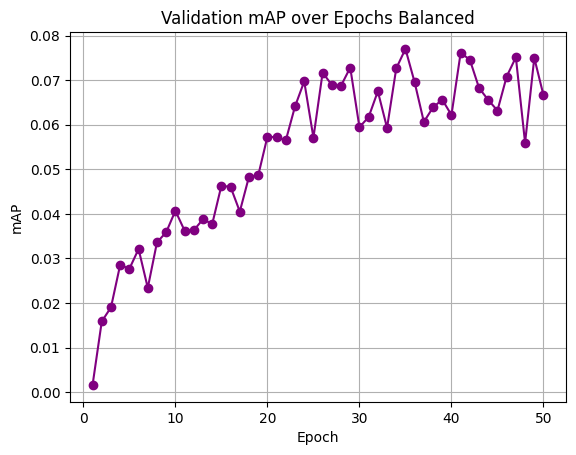

In [95]:
plt.plot(range(1, num_epochs_2+ 1), val_maps_2, 'o-', color='purple')
plt.title("Validation mAP over Epochs Balanced")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.grid(True)
plt.show()

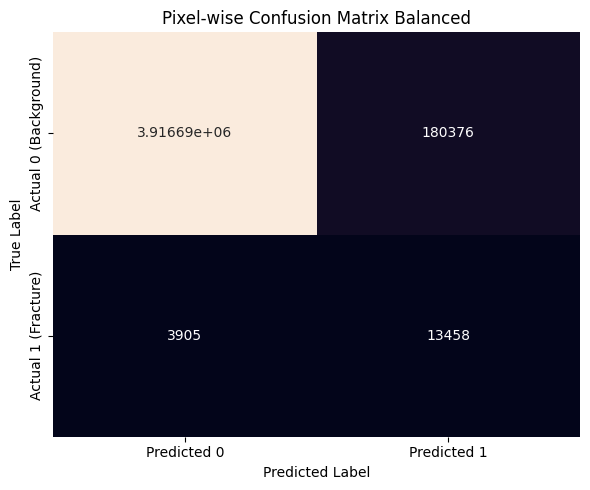

In [96]:
# Build confusion matrix DataFrame
cm_df_2 = pd.DataFrame(
    [[conf_matrix_2['TN'], conf_matrix_2['FP']],
     [conf_matrix_2['FN'], conf_matrix_2['TP']]],
    index=["Actual 0 (Background)", "Actual 1 (Fracture)"],
    columns=["Predicted 0", "Predicted 1"]
)

# Display heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df_2, annot=True, fmt='g', cbar=False)
plt.title("Pixel-wise Confusion Matrix Balanced")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

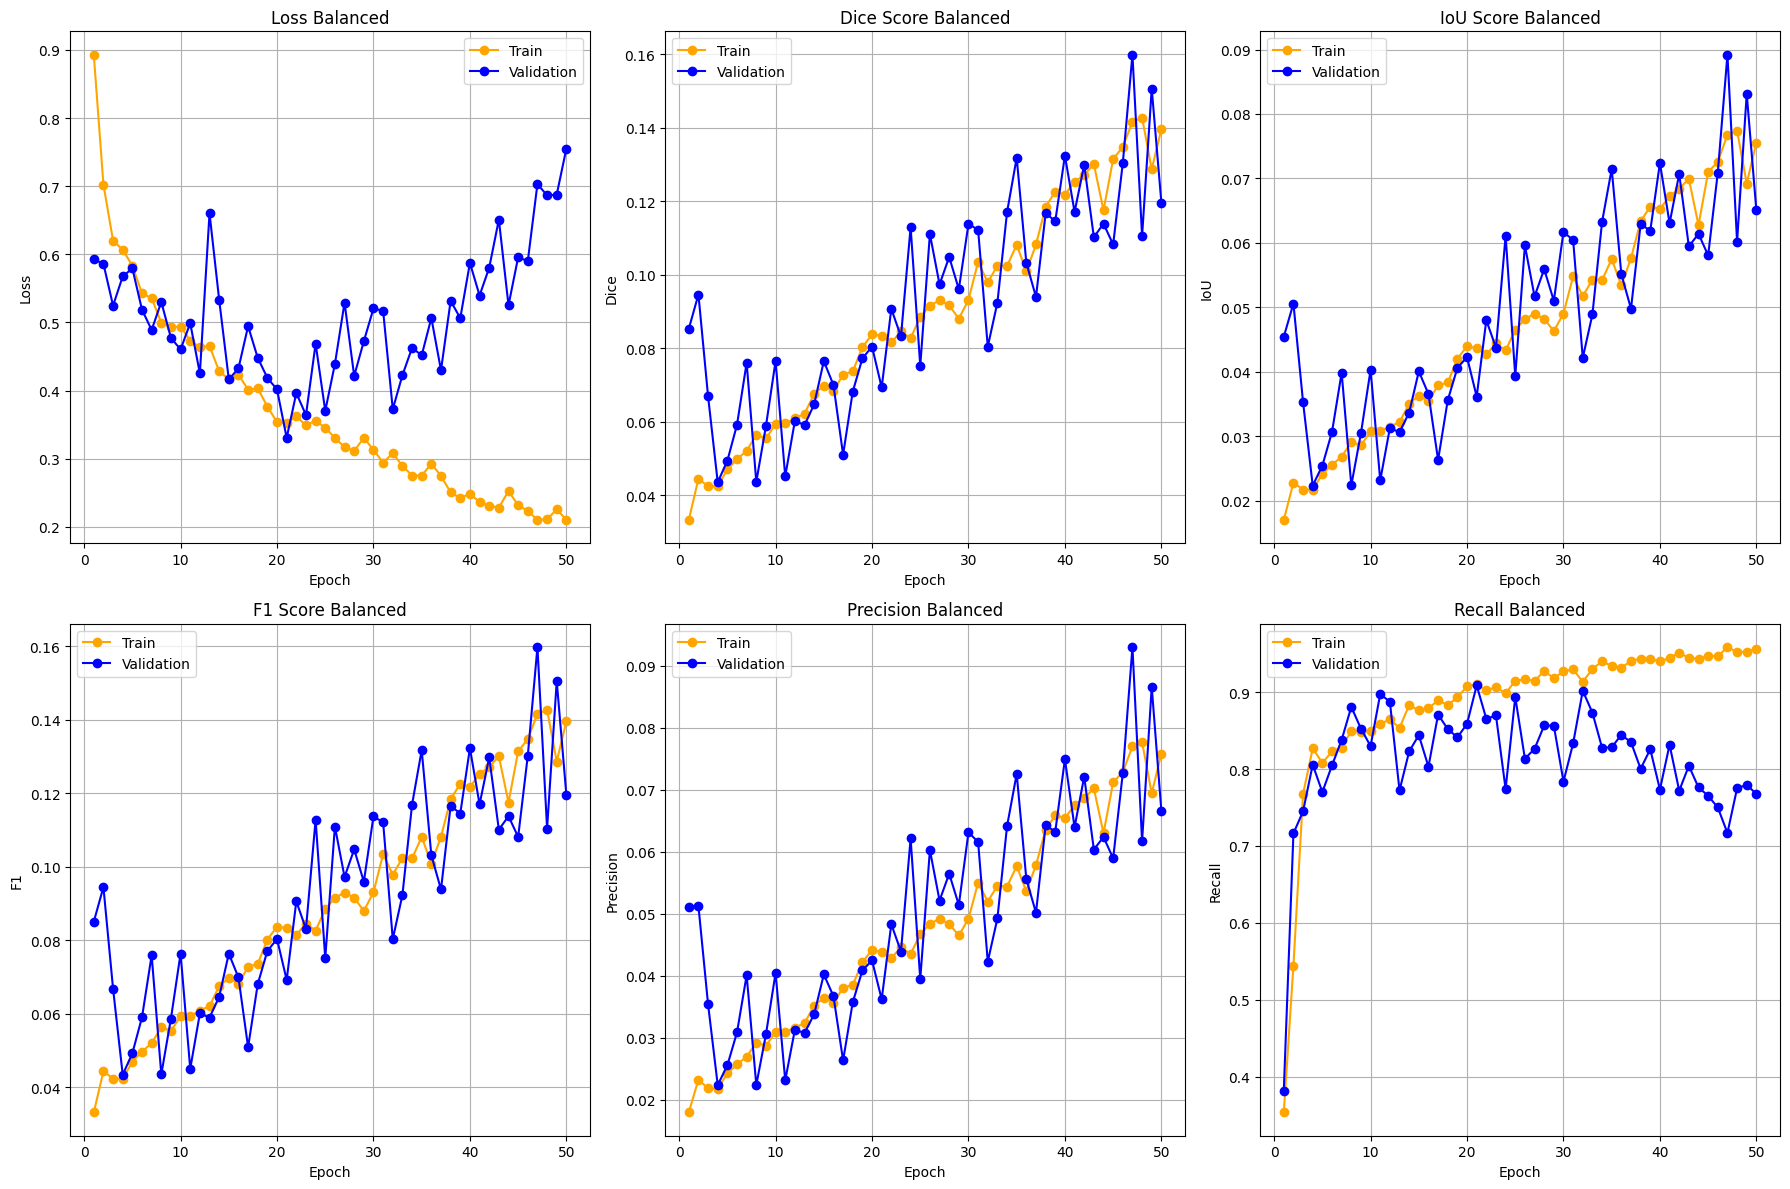

In [97]:
epochs_2 = list(range(1, num_epochs_2 + 1))

def plot_metric(title, train_values_2, val_values_2, ylabel):
    plt.plot(epochs, train_values_2, 'o-', color='orange', label='Train')
    plt.plot(epochs, val_values_2, 'o-', color='blue', label='Validation')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plot_metric("Loss Balanced", train_losses_2, val_losses_2, "Loss")

plt.subplot(2, 3, 2)
plot_metric("Dice Score Balanced", train_dices_2, val_dices_2, "Dice")

plt.subplot(2, 3, 3)
plot_metric("IoU Score Balanced", train_ious_2, val_ious_2, "IoU")

plt.subplot(2, 3, 4)
plot_metric("F1 Score Balanced", train_f1s_2, val_f1s_2, "F1")

plt.subplot(2, 3, 5)
plot_metric("Precision Balanced", train_precisions_2, val_precisions_2, "Precision")

plt.subplot(2, 3, 6)
plot_metric("Recall Balanced", train_recalls_2, val_recalls_2, "Recall")

plt.tight_layout()
plt.show()

Image ID: IMG0003803.jpg


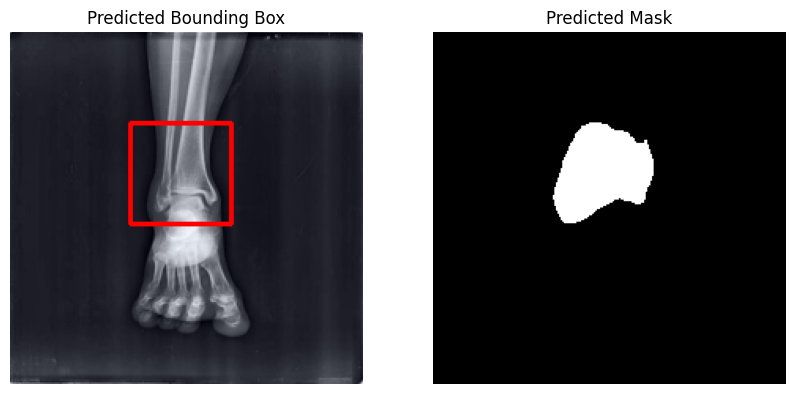

In [98]:
# Show bounding box prediction on test image
show_prediction_with_box(model_2, val_2_dataset, index=11)

Image ID: IMG0003798.jpg


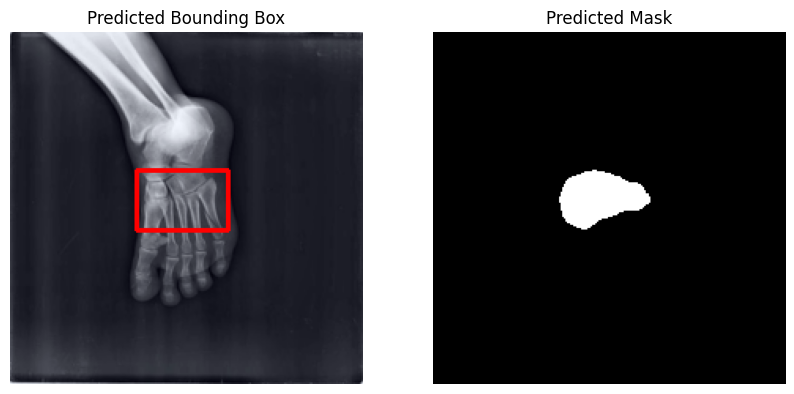

In [99]:
# Show bounding box prediction on test image
show_prediction_with_box(model_2, val_2_dataset, index=10)

Raw image with COCO boxes: IMG0003803.jpg
GT Box 1: x=154, y=191, w=16, h=23


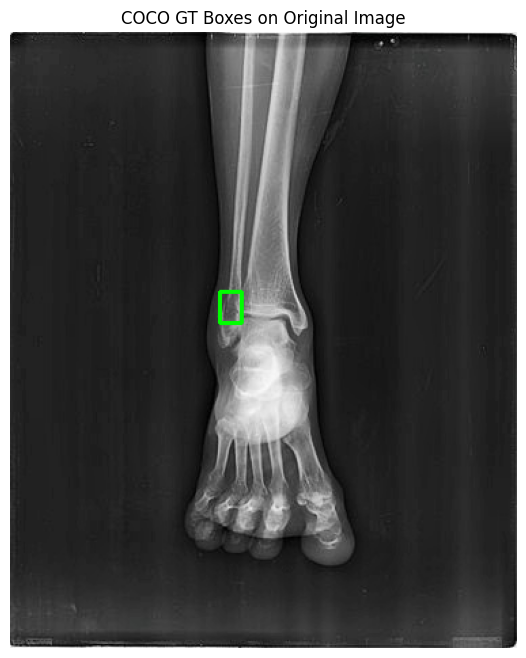

In [100]:
show_coco_box_from_original_image(val_2_dataset, index=11)

Raw image with COCO boxes: IMG0003798.jpg
GT Box 1: x=201, y=227, w=27, h=37


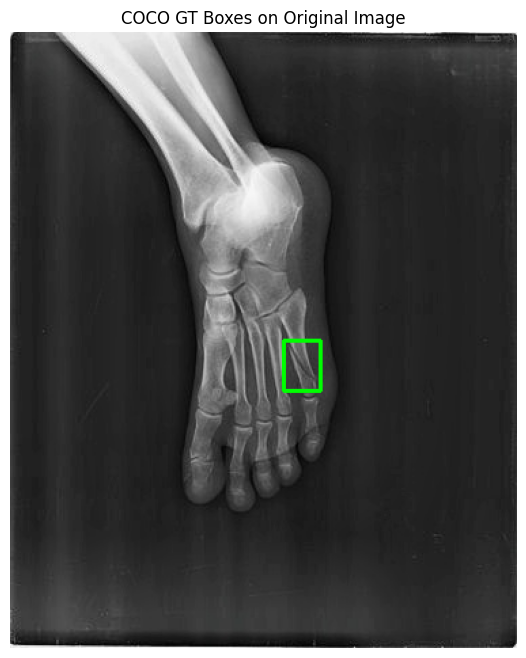

In [101]:
show_coco_box_from_original_image(val_2_dataset, index=10)